# Вторая лабораторная – детектор выстрела и детектор событий

## 1. Детектор выстрела

In [95]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [96]:
audiopath = "Стрельба на улице.wav"
n_fft = 2048
hop_length = 512

In [97]:
y, sr = librosa.load(audiopath)
spec = np.abs(librosa.stft(y, n_fft=n_fft))
spec.shape

(1025, 685)

In [98]:
summed_windows = np.sum(spec, axis=0)

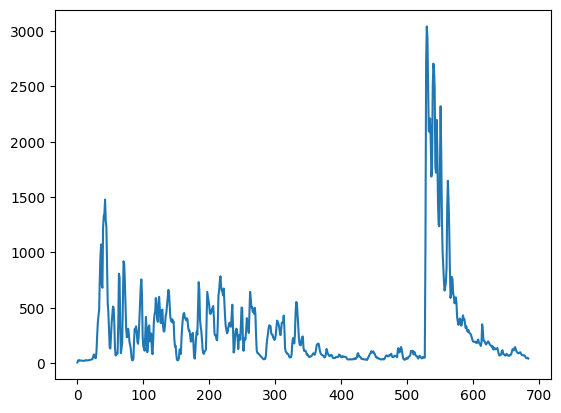

In [99]:
plt.plot(summed_windows)
plt.show()

В начале разговор, потом всплеск выстрела

Улучшим результат с помощью high-pass фильтра

In [100]:
def butter_filter(data, cutoff, fs, filter_type, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype=filter_type)
    return filtfilt(b, a, data)

In [101]:
y_filtered = butter_filter(y, 7000, sr, "high")

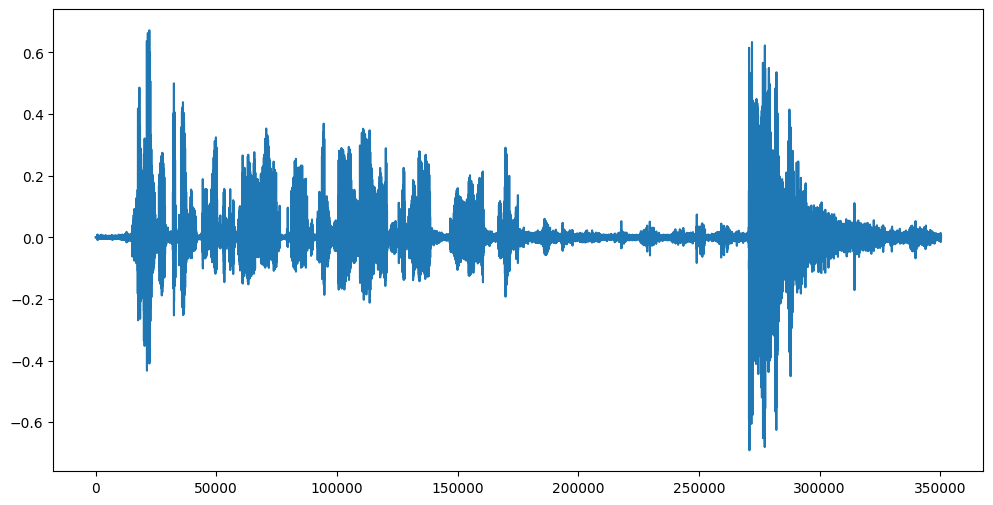

In [102]:
plt.figure(figsize=(12, 6))
plt.plot(y)
plt.show()

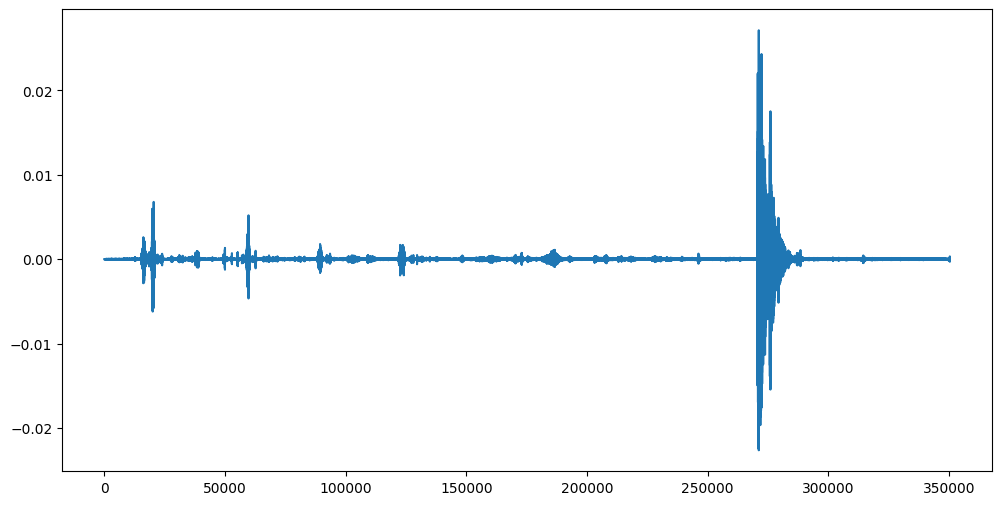

In [103]:
plt.figure(figsize=(12, 6))
plt.plot(y_filtered)
plt.show()

Получаем спектр для отфильтрованного сигнала

In [104]:
spec_filtered = np.abs(librosa.stft(y_filtered, n_fft=n_fft))

In [105]:
summed_windows_filtered = np.sum(spec_filtered, axis=0)

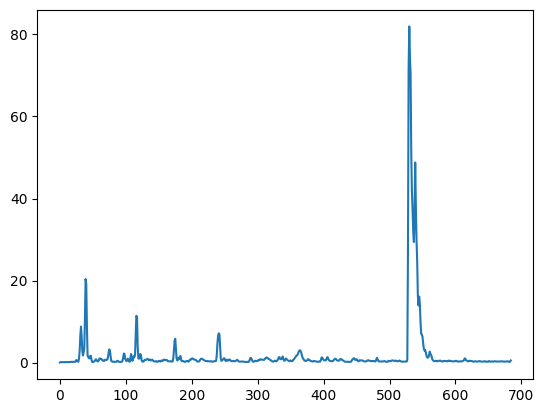

In [106]:
plt.plot(summed_windows_filtered)
plt.show()

Делаем адаптивный пороговый детектор

In [107]:
# Делаем простой порог от максимума
threshold = np.max(summed_windows_filtered) / 4

In [108]:
# Получаем массив окон со значениями 1 и 0, где 1 – выстрел, а 0 – нет выстрела
is_gunshot = (summed_windows_filtered > threshold).astype(int)
gunshot_window_indices = np.where(is_gunshot == 1)[0]
gunshot_window_indices

array([528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 540,
       541, 542])

Интерполируем на отсчеты

In [109]:
is_gunshot_samples = np.repeat(is_gunshot, hop_length)

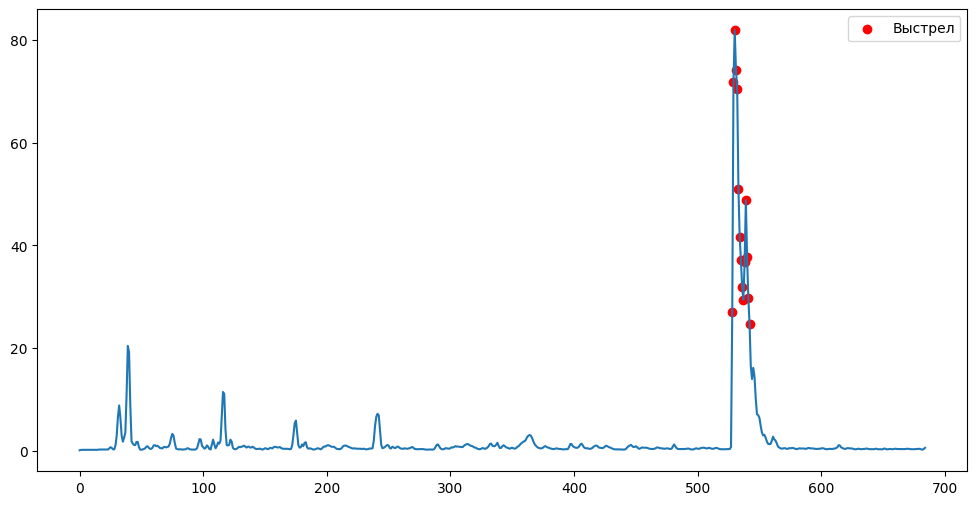

In [110]:
plt.figure(figsize=(12,6))
plt.plot(summed_windows_filtered)

plt.scatter(
    gunshot_window_indices,
    summed_windows_filtered[gunshot_window_indices],
    color="red",
    label="Выстрел"
)

plt.legend()
plt.show()

## 2. AED на RandomForest

In [128]:
import os
import librosa
import zipfile
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [112]:
archive = "audio_train.zip"
directory_to_extract_to = "lab2_dataset"
os.makedirs(directory_to_extract_to, exist_ok=True)

In [113]:
train_labels_path = "lab2_train.csv"
train_labels = pd.read_csv(train_labels_path, index_col="fname")

In [114]:
# Извлекаем из .zip файлы
with zipfile.ZipFile(archive, 'r') as zip_file:
    zip_file.extractall(directory_to_extract_to)

In [120]:
# Извлекаем тоновый спектр
def extract_features(filepath):
    y, sr = librosa.load(filepath)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    return np.mean(chroma, axis=1)

In [121]:
X = []
Y = []
for dirpath, dirnames, filenames in os.walk(directory_to_extract_to):
    for filename in filenames:
        full_path = os.path.join(dirpath, filename)
        X.append(extract_features(full_path))
        Y.append(train_labels.loc[filename].label)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


In [122]:
le = LabelEncoder()
Y_num = le.fit_transform(Y)

In [131]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_num, test_size=0.2, random_state=42)

In [134]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "min_samples_leaf": [1, 3, 5],
    "max_depth": [5, 9, 12],
    "class_weight": ["balanced", None],
    "max_features": ["sqrt", "log2", None]
}

model = RandomForestClassifier()
clf = GridSearchCV(
    model,
    param_grid,
    n_jobs=-1)

In [135]:
clf.fit(X_train, Y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'class_weight': ['balanced', None], 'max_depth': [5, 9, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 3, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [136]:
best_params = clf.best_params_
best_params

{'class_weight': None,
 'max_depth': 12,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'n_estimators': 300}

In [141]:
best_clf = clf.best_estimator_

In [142]:
Y_pred = best_clf.predict(X_test)
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.19      0.33      0.24        33
           1       0.17      0.35      0.23        34
           2       0.06      0.03      0.04        36
           3       0.29      0.38      0.33        32
           4       0.08      0.04      0.06        23
           5       0.00      0.00      0.00        14
           6       0.27      0.23      0.25        40
           7       0.25      0.05      0.08        20
           8       0.35      0.61      0.44        33
           9       0.00      0.00      0.00        14
          10       0.00      0.00      0.00        35
          11       0.43      0.60      0.50        15
          12       0.33      0.41      0.37        44
          13       0.12      0.04      0.06        25
          14       0.40      0.20      0.27        20
          15       0.22      0.04      0.07        45
          16       0.50      0.50      0.50        14
          17       0.19    

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha